# 1,000 OGLE light curves: catalog periods and paper-aligned JDR

This notebook uses **known OGLE periods and epochs directly**, compares five clustering models, and exports the same four publication figure sets. The sample contains 1,000 original Galactic Disk I-band light curves.

The reference is the supplied manuscript *Comparing irregular sampled time series using the Jensen-distance rate*, by Contreras-Reyes, Pérez-Galarce and Ojeda, archived unchanged at `review/jdr_paper_1000/reference.pdf`. Its SHA-256 is recorded. **Equation 6 is interpreted as a product of complex spectral amplitudes, explicitly approved by the user.** The real cross-spectrum then enters Equation 7. This clarification is essential: the literal product of two power spectra is not a valid distance. The notebook does not claim a literal reproduction of that inconsistent reading.

The 500-object implementation used different spectral coefficients, a different integration measure/band, estimated periods and smoothed curve inputs. Those choices are replaced here. Therefore, score changes are **not** an isolated effect of increasing sample size.

The entire notebook runs locally. Every execution rebuilds the features and distance matrices; a second complete computation checks exact repeatability in the recorded Python environment. No cloud computation, period search, simulated augmentation or implicit distance cache is used.

In [1]:
from pathlib import Path
import os, sys, json, tempfile
os.environ.setdefault('LOKY_MAX_CPU_COUNT','1')
ROOT=next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src'/'study1000.py').exists())
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown
from src.study1000 import DATA,PROTOCOL1000,cohort1000,run_study1000,compare_study1000
from src.benchmark import MODEL_NAMES
from src.publication_figures1000 import make_figures
OUTPUT=ROOT/'results'/'benchmark_1000'
display(pd.Series(PROTOCOL1000,name='Fixed protocol').to_frame())

,Fixed protocol
version,3
n_objects,1000
seed,20260912
n_clusters,3
n_init,20
dbscan_min_samples,5
dbscan_eps_quantile,0.7
hdbscan_min_cluster_size,5
hdbscan_min_samples,5
subsamples,30


## 1. Original data and the known-period policy

Data are from [OGLE OCVS Galactic Disk RR Lyrae](https://www.astrouw.edu.pl/ogle/ogle4/OCVS/gd/rrlyr/); cite [Soszyński et al. (2019), Acta Astronomica 69, 321](https://arxiv.org/abs/2001.00025). The archived catalogs and `phot.tar.gz` define this experiment, since the online catalog may change.

`scripts/prepare_ogle1000.py` extends the **same seeded candidate permutation** used for 500 objects (seed 20260912). It selects the first 1,000 eligible I-band curves, then sorts IDs once for all arrays. Eligibility remains: RRab/RRc/RRd subtype, at least 30 original observations, finite values, positive reported errors, unique timestamps, nonconstant signal, catalog period, and no duplicate ID/content. The catalog epoch is also required. Eleven of the first 1,011 candidates fail the observation-count threshold. There are **778 RRab, 214 RRc and 8 RRd**. This is an eligibility-conditioned sample, not a balanced subtype study.

Catalog metadata are parsed using the fixed-width specification: ID bytes 1–19, subtype 22–25 in `ident.dat`; period bytes 37–46 and epoch 60–69 in the subtype catalogs. RRd additionally records its fundamental period/epoch, but the primary analysis consistently uses its catalog **first-overtone** mode. No period is estimated or optimized. Each selected period and epoch is checked against the original catalog before analysis.

Raw columns are observation time in days in the OGLE offset convention, I magnitude, and uncertainty in magnitudes. With the catalog period $P_i$ and maximum-brightness epoch $T_{0i}$, use

$$\phi_{ir}=\operatorname{frac}\left[(t_{ir}-T_{0i})/P_i\right].$$

The original measurements are sorted by phase and retained at their **irregular phases**. There is no clipping, interpolation, resampling, smoothing or synthetic measurement in the JDR input. Exact duplicate folded phases stop execution rather than trigger silent aggregation. Center and standardize magnitudes using the population standard deviation. This removes offset and positive amplitude scaling as an explicit preprocessing choice.

Photometric uncertainties are preserved, but Equation 1 is the manuscript's **unweighted** projection estimator. We do not insert uncertainty weights into that formula and still call it the same estimator. For Figure 1b only, uncertainty-weighted harmonic fits of orders 1–4 at the fixed catalog period/epoch are selected using a BIC-style criterion and evaluated at 256 phases. These display curves never enter JDR. Catalog-period errors, mode mixing and modulation are not propagated by this experiment.

In [2]:
files,cohort,acquisition=cohort1000()
assert len(files)==1000 and cohort.object_id.is_unique and cohort.sha256.is_unique
old_ids=set(pd.read_csv(ROOT/'data'/'ogle_gd_500'/'cohort.csv').object_id)
assert old_ids.issubset(set(cohort.object_id))
display(pd.crosstab(cohort.region,cohort.catalog_type,margins=True))
display(cohort[['n_observations','baseline_days','catalog_period']].describe())
display(pd.read_csv(DATA/'eligibility_exclusions.csv'))
print('Original observations:',int(cohort.n_observations.sum()))
print('Unique unordered pairs:',1000*999//2)

catalog_type,RRab,RRc,RRd,All
region,,,,
GD,778,214,8,1000
All,778,214,8,1000


,n_observations,baseline_days,catalog_period
count,1000.000000,1000.000000,1000.000000
mean,120.081000,1579.617699,0.500945
std,32.950359,665.378378,0.132351
min,33.000000,156.657060,0.213992
25%,101.750000,918.725002,0.405072
50%,123.000000,1633.609860,0.517706
75%,145.000000,2236.885877,0.591098
max,212.000000,2515.856460,0.950237


,object_id,candidate_rank,reason
0,OGLE-GD-RRLYR-00757,71,Fewer than 30 observations for periodic shape ...
1,OGLE-GD-RRLYR-10308,86,Fewer than 30 observations for periodic shape ...
2,OGLE-GD-RRLYR-11518,184,Fewer than 30 observations for periodic shape ...
3,OGLE-GD-RRLYR-04129,244,Fewer than 30 observations for periodic shape ...
4,OGLE-GD-RRLYR-03432,332,Fewer than 30 observations for periodic shape ...
5,OGLE-GD-RRLYR-11628,404,Fewer than 30 observations for periodic shape ...
6,OGLE-GD-RRLYR-04535,592,Fewer than 30 observations for periodic shape ...
7,OGLE-GD-RRLYR-02804,714,Fewer than 30 observations for periodic shape ...
8,OGLE-GD-RRLYR-01772,787,Fewer than 30 observations for periodic shape ...
9,OGLE-GD-RRLYR-06838,864,Fewer than 30 observations for periodic shape ...


Original observations: 120081
Unique unordered pairs: 499500


## 2. Equation 1: the actual Lomb–Scargle projections

For a centered, standardized curve $x(t_r)$, define $\theta(\omega)=\omega\tau(\omega)$, where the printed expression is

$$\tau(\omega)=\frac{1}{2\omega}\arctan\left[\frac{\sum_r\sin(2\omega t_r)}{\sum_r\cos(2\omega t_r)}\right].$$

Here the time coordinate is the catalog-folded phase. The implementation uses `atan2` to choose a stable branch. The projections onto **unit-norm trigonometric vectors** are

$$C_i(\omega)=\frac{\sum_r x_{ir}\cos(\omega t_{ir}-\theta_i)}{\sqrt{\sum_r\cos^2(\omega t_{ir}-\theta_i)}},\quad
S_i(\omega)=\frac{\sum_r x_{ir}\sin(\omega t_{ir}-\theta_i)}{\sqrt{\sum_r\sin^2(\omega t_{ir}-\theta_i)}}.$$

Thus Equation 1 is exactly

$$\widehat f_i(\omega)=\tfrac12\left[C_i(\omega)^2+S_i(\omega)^2\right].$$

These are **not** least-squares sinusoid amplitudes divided by squared basis norms, and no floating intercept is added after centering. Tests compare this power with Astropy's classical Lomb–Scargle PSD normalization (`fit_mean=False`, centered input), as an independent implementation.

At $\omega=0$, the written sine denominator vanishes. Quadrature uses the continuous right-hand limit: for centered $x$, $C_i\to0$ and $S_i\to\sum_r x_{ir}(t_{ir}-\bar t_i)/\sqrt{\sum_r(t_{ir}-\bar t_i)^2}$. A test checks this limit numerically. This endpoint treatment is documented, not an arbitrary positive lower-frequency cutoff.

Equation 1's power depends on observation count and sampling geometry. Standardizing magnitudes does **not** remove that dependence. Keeping the printed projection normalization prioritizes consistency with the paper over the sampling-count normalization of the previous implementation.

## 3. Equation 6 clarification and Equation 7 spectral integrals

The manuscript uses $f_i$ for power density in Equation 1 and then writes a product $f_i\overline f_j$ for the cross-spectrum in Equation 6. If those factors are literally the powers, self-comparison gives an integrand $2f_i-2f_i^2$, generally nonzero and potentially negative. This cannot serve as a distance. The numerical audit below includes that counterexample without feeding it to a clustering algorithm.

**Approved interpretation:** define the common-basis complex amplitude

$$A_i(\omega)=\frac{C_i(\omega)+\mathrm{i}S_i(\omega)}{\sqrt2}\exp[\mathrm{i}\theta_i(\omega)],\qquad |A_i|^2=\widehat f_i.$$

The rotation restores the same phase coordinate across sampling-dependent $\tau_i$ values and makes the amplitude invariant to equivalent arctangent branches. Using the conjugate convention for every amplitude gives the same real cross-spectrum. Define

$$\widehat f_{ij}(\omega)=A_i(\omega)\overline{A_j(\omega)},\qquad
\operatorname{co}_{ij}(\omega)=\operatorname{Re}\widehat f_{ij}(\omega).$$

The real part is necessary for a real-valued dissimilarity. With $\beta=\alpha(1-\alpha)$ and $\alpha=1/2$, Equation 7 becomes

$$I_i=\int_0^{2\pi}|A_i(\omega)|^2\,d\omega,\quad
I_j=\int_0^{2\pi}|A_j(\omega)|^2\,d\omega,\quad
I_{ij}=\int_0^{2\pi}\operatorname{Re}[A_i(\omega)\overline{A_j(\omega)}]\,d\omega,$$

$$J_{ij}=\frac{\beta}{2\pi}\left(I_i+I_j-2I_{ij}\right)
=\frac{\beta}{2\pi}\int_0^{2\pi}|A_i(\omega)-A_j(\omega)|^2\,d\omega.$$

We use the manuscript's **angular-frequency interval $[0,2\pi]$ and measure $d\omega$**. Equivalently, with cyclic frequency $f=\omega/(2\pi)$, this is $\beta\int_0^1|A_i(2\pi f)-A_j(2\pi f)|^2df$; the Jacobian must not be lost. The earlier $[0.5,6]$ cyclic-frequency integral is not used here.

Because the time coordinate is phase in $[0,1)$, the upper bound corresponds to one cycle per phase unit. The manuscript does not prescribe this folding convention; it is an explicit known-period application choice. Higher harmonics are not directly spanned by extending the upper limit, and the band may limit discrimination of waveform detail. We keep the printed band rather than silently tuning it for catalog scores.

The approved interpretation makes $J$ a **squared Euclidean dissimilarity**. It is symmetric, nonnegative and zero for identical representations, but generally does **not** obey the triangle inequality claimed in the draft. Its square root does. A regression test demonstrates this distinction with a simple counterexample; we do not claim to have proved the manuscript's listed properties. Multitaper Equations 8–9 and multiband methods are outside this LSP experiment.

## 4. Efficient quadrature and validation

With $M$ angular-frequency nodes and positive trapezoidal weights $q_k$ (half weights at endpoints), concatenate

$$z_i=\left[\sqrt{\frac{\beta q_k}{2\pi}}\operatorname{Re} A_i(\omega_k),\;
\sqrt{\frac{\beta q_k}{2\pi}}\operatorname{Im} A_i(\omega_k)\right]_{k=1}^{M}.$$

Then the grid approximation is exactly $J_{ij}=\|z_i-z_j\|^2$. Each curve is transformed once per grid; 499,500 pair distances use the resulting vectors. At $M=4097$, the 1,000-by-8,194 float64 embedding is about 65.6 MB, and each full matrix is about 8 MB. Peak memory includes multiple matrices and temporary arrays.

We rebuild all matrices at 1,025, 2,049 and 4,097 angular frequencies. Every entry must satisfy `rtol=1e-3, atol=1e-8` between consecutive grids, with identical nearest-neighbor IDs. We also recompute all features after a permutation of objects.

For pairs near the 10th, 50th and 90th distance percentiles, an independent **scalar** implementation using the printed arctangent ratio computes the three integrals with adaptive SciPy quadrature in $d\omega$. It does not call the vectorized amplitude implementation. Nonconvergence or disagreement stops the run. These three pairs audit the integral computation; the grid test covers every pair. Numerical agreement is not proof of astrophysical validity.

## 5. Clustering models and the paper's K-medoids objective

The paper's Equations 10–12 and Algorithm 1 minimize sums of the supplied JDR dissimilarity. Accordingly, the primary K-medoids run receives **$J$ itself**, not $\sqrt J$. It alternates nearest-medoid assignment and within-cluster medoid updates; the best of 20 seeded initializations is selected by its objective, never by catalog labels.

| Model | Primary input and policy |
|---|---|
| K-medoids | $J$; $K=3$; 20 starts; sum of J to medoids |
| K-means | Full $z$; $K=3$; 20 starts; squared Euclidean objective in the same embedding |
| Average linkage | $J$; $K=3$ |
| DBSCAN | $J$; minimum samples 5 including self; radius is the 70th percentile of the corresponding per-star neighbor J values |
| HDBSCAN | $J$; minimum cluster size 5, minimum samples 5 |

$K=3$ is a subtype-informed comparison assumption, not evidence of three discovered physical populations. Density methods may produce different numbers of groups and noise. Passing J versus its square root can change average linkage, medoid objectives, density stability and silhouette. The notebook does not claim those choices are interchangeable. K-means centroid objectives and medoid objectives also differ despite sharing the embedding.

All-star ARI/AMI retain noise as label −1. Coverage, assigned-only purity/ARI and per-subtype retention accompany them. Silhouettes in the tables use **J dissimilarities**. Thirty shared seeded 800-star subsets refit the clustering policies; their ARI quantiles describe partition stability, not confidence intervals or photometric/period uncertainty. The 54-point DBSCAN sweep is fully reported and does not select primary settings. PCA is used only to display the embedding.

In [3]:
run_study1000(OUTPUT)
summary=json.loads((OUTPUT/'summary.json').read_text())
scores=pd.read_csv(OUTPUT/'model_comparison.csv').set_index('model').loc[MODEL_NAMES]
processed=pd.read_csv(OUTPUT/'cohort.csv')
assert np.array_equal(processed.period.to_numpy(),processed.catalog_period.to_numpy())
assert np.array_equal(processed.epoch.to_numpy(),processed.catalog_epoch.to_numpy())
with np.load(OUTPUT/'experiment.npz',allow_pickle=False) as a:
    J=a['J'].copy()
    assert a['features'].shape==(1000,8194) and J.shape==(1000,1000)
    assert np.array_equal(a['distance'],J)
    assert np.allclose(a['euclidean_distance']**2,J)
    assert a['object_ids'].tolist()==cohort.object_id.tolist()
    assert np.diff(a['raw_offsets']).tolist()==cohort.n_observations.tolist()
assert np.isfinite(J).all() and np.all(J>=0) and np.array_equal(np.diag(J),np.zeros(1000))
assert np.allclose(J,J.T)
assert summary['permutation_invariance'] and summary['fit_info']['dbscan_reference_agreement']
display(pd.DataFrame(summary['grid_convergence']))
display(pd.read_csv(OUTPUT/'spectral_integral_audit.csv'))
equation_audit=json.loads((OUTPUT/'equation_audit.json').read_text())
assert equation_audit['eq1_scalar_reference_max_abs_error']<1e-8
assert equation_audit['clarified_self_j']==0
display(pd.Series(equation_audit,name='Equation audit').to_frame())
display(pd.Series(json.loads((OUTPUT/'timing.json').read_text()),name='Measured local runtime').to_frame())

Prepared 1000 curves using catalog periods; no period search.


Paper JDR grid 1025 complete.


Paper JDR grid 2049 complete.


Paper JDR grid 4097 complete.


Five primary clustering models fitted; running stability refits.


,coarse_grid,fine_grid,relative_max_error,all_pairs_close,neighbor_agreement
0,1025,2049,6.778418e-08,True,1.0
1,2049,4097,1.694605e-08,True,1.0


,distance_quantile,object_i,object_j,integral_xx,integral_yy,integral_xy_real,j_adaptive,quad_error_bound_j,j_grid,relative_difference,passed
0,0.1,OGLE-GD-RRLYR-00664,OGLE-GD-RRLYR-10881,188.691952,148.515386,166.838085,0.140501,3.467810e-10,0.140501,3.462560e-08,True
1,0.5,OGLE-GD-RRLYR-01957,OGLE-GD-RRLYR-02639,173.007950,129.134208,137.062265,1.114786,3.967292e-11,1.114786,5.323787e-09,True
2,0.9,OGLE-GD-RRLYR-09132,OGLE-GD-RRLYR-09264,129.805695,208.760135,97.296300,5.728513,2.293458e-10,5.728513,4.556237e-10,True


,Equation audit
eq1_scalar_reference_max_abs_error,0.0
literal_power_product_self_j,-422.945226
literal_self_object,OGLE-GD-RRLYR-00001
clarified_self_j,0.0
clarification,User approved complex-amplitude cross-spectrum...
paper_pdf_sha256,c91bbcc0a11ebed8051c7b98265c22db6a82c6d5f73524...


,Measured local runtime
elapsed_seconds,48.259932
scope,"Full local 1000-curve analysis, all grids, pri..."
execution,"Local Python, one numerical thread."


## 6. Results and stability

These are computed results for the 1,000-star cohort under the revised, explicitly documented representation. All catalog periods are inputs; agreement with those same periods would be tautological and is not presented as a period-recovery test.

In [4]:
display(scores[['ari_all','ami_all','coverage','n_clusters','n_noise','purity_assigned','ari_assigned','silhouette_assigned']].round(4))
retention=pd.DataFrame({name:summary['models'][name]['class_retention'] for name in MODEL_NAMES}).T
display(retention.rename_axis('model').round(3))
stability=pd.read_csv(OUTPUT/'subsampling_stability.csv')
assert len(stability)==30*5
memberships=json.loads((OUTPUT/'subsample_membership.json').read_text())
assert len(memberships)==30 and all(len(set(ids))==800 for ids in memberships)
stability_summary=stability.groupby('model').ari_stability_all.quantile([.1,.5,.9]).unstack().reindex(MODEL_NAMES)
stability_summary.columns=['10th percentile','Median','90th percentile']
display(stability_summary.round(3))
assert len(pd.read_csv(OUTPUT/'dbscan_sensitivity.csv'))==54

,ari_all,ami_all,coverage,n_clusters,n_noise,purity_assigned,ari_assigned,silhouette_assigned
model,,,,,,,,
K-medoids,0.2919,0.3654,1.000,3,0,0.9150,0.2919,0.5889
K-means,0.3070,0.3737,1.000,3,0,0.9180,0.3070,0.5929
Average linkage,0.6730,0.5037,1.000,3,0,0.9130,0.6730,0.7049
DBSCAN,0.5352,0.3710,0.820,8,180,0.9549,0.7718,0.3188
HDBSCAN,0.2424,0.2537,0.637,7,363,0.9545,0.6450,-0.0872


,RRab,RRc,RRd
model,,,
K-medoids,1.000,1.000,1.000
K-means,1.000,1.000,1.000
Average linkage,1.000,1.000,1.000
DBSCAN,0.877,0.612,0.875
HDBSCAN,0.689,0.449,0.625


,10th percentile,Median,90th percentile
model,,,
K-medoids,0.852,0.983,1.000
K-means,0.911,0.982,0.997
Average linkage,0.542,0.797,0.949
DBSCAN,0.876,0.891,0.931
HDBSCAN,0.464,0.553,0.730


## 7. Independent full recomputation

Repeat every raw-data read, catalog fold, spectral grid, object-permutation check, clustering model, subsampling refit, sensitivity calculation, PCA and scalar integral audit in a temporary directory. Compare numerical arrays exactly, tables byte-for-byte, and semantic provenance. Timing differences and compressed-container timestamps are intentionally excluded. Only the duplicate directory is removed after verification; the primary results and repeatability report remain.

In [5]:
with tempfile.TemporaryDirectory(prefix='jdr1000-repeat-') as temporary:
    repeat=run_study1000(Path(temporary))
    repeat_timing=json.loads((repeat/'timing.json').read_text())
    reproducibility=compare_study1000(OUTPUT,repeat)
assert reproducibility['arrays_identical'] and reproducibility['tables_identical']
(OUTPUT/'repeat_timing.json').write_text(json.dumps(repeat_timing,indent=2)+'\n')
display(pd.Series(reproducibility,name='Verification').to_frame())

Prepared 1000 curves using catalog periods; no period search.


Paper JDR grid 1025 complete.


Paper JDR grid 2049 complete.


Paper JDR grid 4097 complete.


Five primary clustering models fitted; running stability refits.


,Verification
independent_full_recomputations,2
arrays_identical,True
tables_identical,True
provenance_identical,True
additional_checks_identical,True
comparison,Exact within the recorded environment; not pro...


## 8. Four publication figure sets

The four sets retain the earlier study's structure: cohort and geometry; agreement, retention and stability; cluster compositions; numerical and DBSCAN sensitivity. Captions now explicitly describe the paper-based coefficients, catalog periods, raw irregular inputs and use of J.

Exports are 183 mm wide, with accessible subtype colors, embedded PDF fonts, editable SVG text and 600-dpi PNGs. The dense distance heatmap is rasterized at 600 dpi inside vector exports; axes, labels and other marks remain vector. Preview images below are lower resolution. Captions and source arrays/tables accompany the publication bundle; final submission still requires the target journal's formatting review.

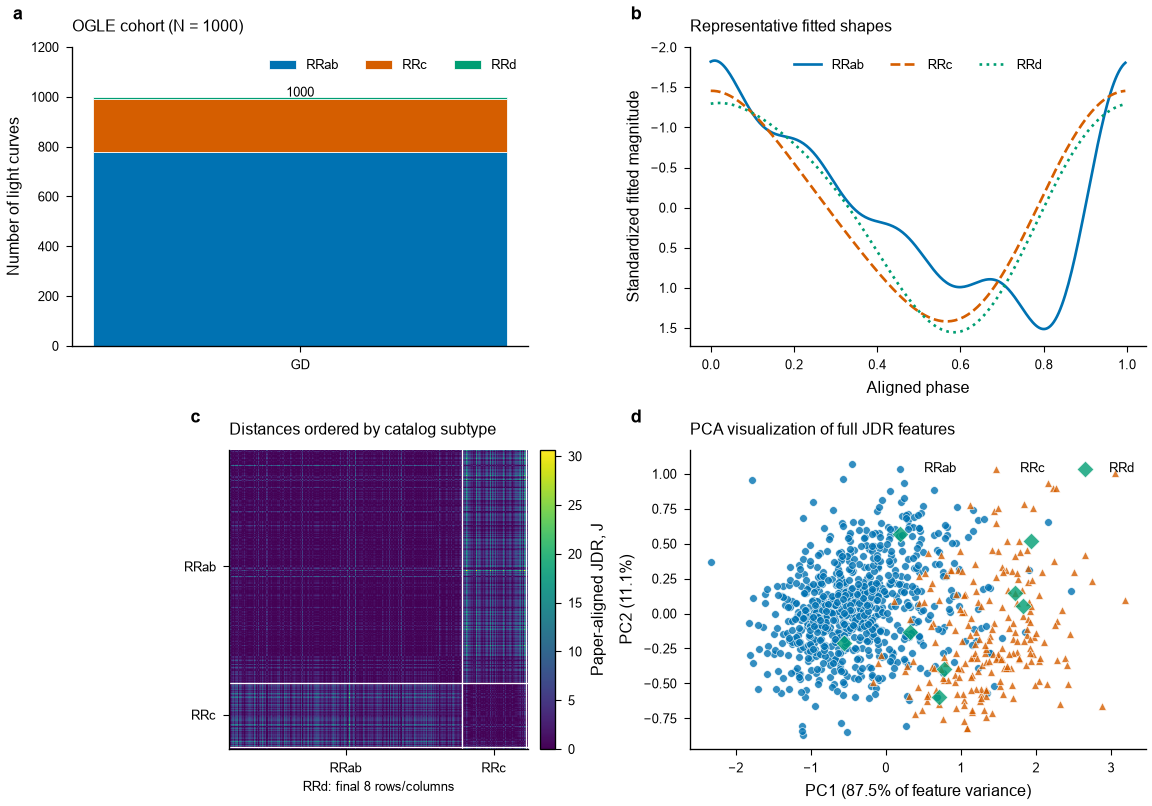

Figure 1 | Catalog-period OGLE cohort and paper-aligned JDR. a, The 1,000 original Galactic Disk I-band curves comprise 778 RRab, 214 RRc and 8 RRd. The sample contains the previous 500 IDs, with an unchanged selection seed. b, Uncertainty-weighted harmonic fits at the catalog period and epoch of within-subtype J-medoids, for display only. JDR uses the original irregular folded observations, not these fitted curves. c, J from Eq. (7), with the approved complex-amplitude cross-spectrum interpretation of Eq. (6), ordered by subtype then ID. The small RRd block is indicated. d, Two-component PCA of the complete quadrature embedding, for display only. Models use J or the full embedding, never the PCA projection. Source IDs and display order are exported.

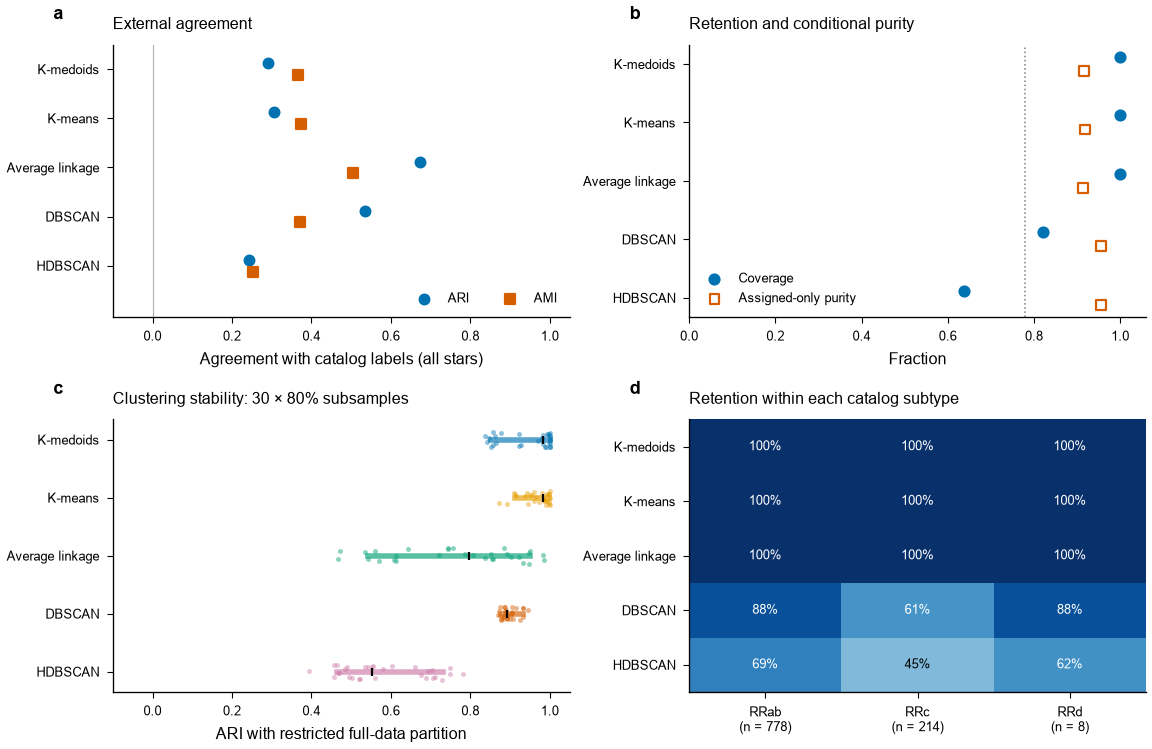

Figure 2 | Fixed-protocol comparison on 1,000 stars. a, All-star ARI and AMI against catalog subtypes; rejected objects retain the common noise label -1. b, Coverage and purity conditional on assignment; the dotted line is the 0.778 majority-class fraction. c, Thirty shared seeded 800-star subsets: clustering is refitted using the fixed model policies, and each partition is compared with the full partition restricted to the same subset. Points are replicate ARIs, thick segments empirical 10th-90th percentiles, ticks medians. These are stability summaries, not confidence intervals or measurement/period uncertainty propagation. d, Subtype retention with denominators. Eight RRd stars do not support rare-class generalization. K-medoids minimizes sums of J as in the paper; K-means minimizes squared Euclidean feature distances, and the other matrix models also receive J. Assigned silhouette, where reported in tables, is calculated in J dissimilarity, not sqrt(J).

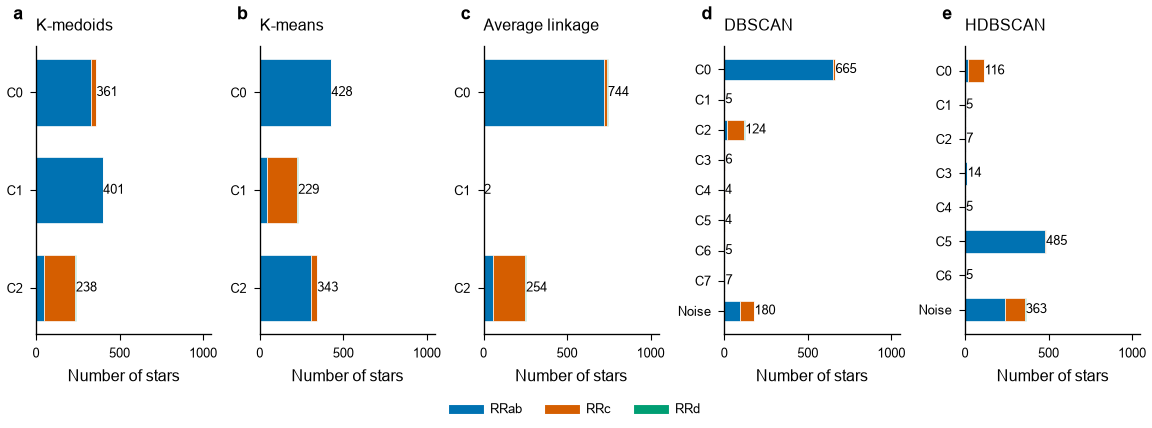

Figure 3 | Composition of every learned cluster. Segment colors denote catalog subtypes and end labels give observed counts. Cluster IDs are arbitrary and need not correspond across methods. Noise is shown explicitly. Every panel uses a 0-1050 count axis; no class relabeling or exclusion of noise is applied. J is the primary dissimilarity for all matrix methods. Bar totals account for all 1,000 stars in each model.

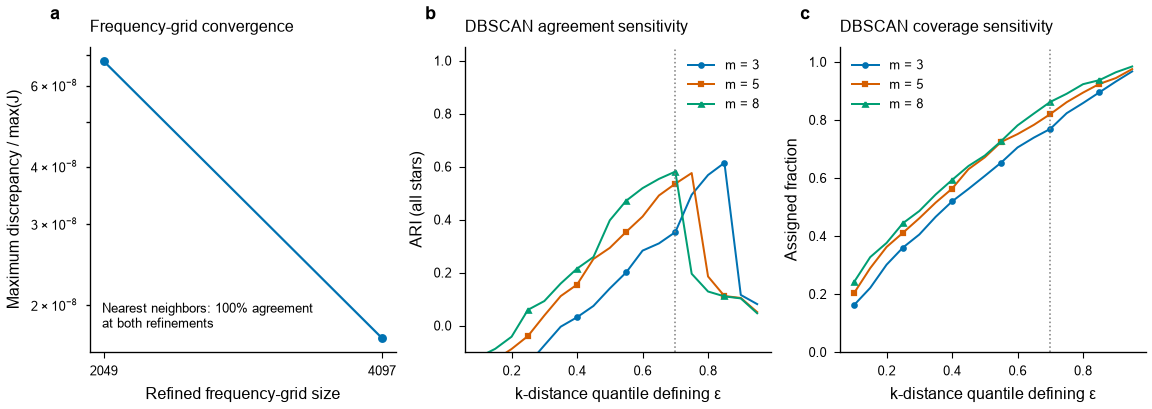

Figure 4 | Numerical integration and model sensitivity. a, J matrices from 1,025, 2,049 and 4,097 angular frequencies over [0, 2*pi] are compared. Every entry meets rtol=1e-3 and atol=1e-8, with unchanged nearest neighbors at both refinements. Independent scalar-reference adaptive quadrature also checks three pairs in the exported integral audit. b,c, All 54 DBSCAN configurations (minimum samples 3, 5 or 8 including self; 18 J-neighbor-distance quantiles from 0.10 to 0.95). The primary policy remains minimum samples 5 and quantile 0.70, marked by the dotted line. These post-fit catalog-score diagnostics do not select the primary model. The study is exploratory and in-sample.

In [6]:
figure_directory=make_figures(OUTPUT)
captions=json.loads((figure_directory/'captions.json').read_text())
for stem,caption in captions.items():
    display(Image(filename=str(figure_directory/f'{stem}_preview.png')))
    display(Markdown(caption))

## 9. Data management, reproduction and scientific limits

| Artifact | Purpose |
|---|---|
| `data/ogle_gd_1000/source/` | Frozen OGLE archive, README and fixed-width catalogs |
| `data/ogle_gd_1000/photometry/` | Original selected files, unchanged |
| `cohort.csv`, `acquisition.json`, `eligibility_exclusions.csv` in the data directory | Ordered selection, seed, IDs, input hashes, metadata and exclusions |
| `results/benchmark_1000/cohort.csv` | Catalog period/epoch actually used, plus display-fit diagnostics |
| `experiment.npz` | J, sqrt(J), full features, raw folded measurements/offsets, display fits and PCA |
| `model_comparison.csv`, `cluster_labels.csv` | Metrics and all labels including noise |
| `spectral_integral_audit.csv`, `equation_audit.json` | Independent integration and literal-equation counterexample |
| `subsample_membership.json`, stability and sensitivity CSVs | Every shared subset and reported diagnostic |
| `provenance.json`, `reproducibility.json`, timing JSONs | Code/data/PDF hashes, environment, exact-repeat checks and measured duration |
| `figures/` | Four figure sets, captions and specifications |

Use Python 3.12 with `results/benchmark_1000/environment-lock.txt` for the recorded environment. The general `requirements-dev.txt` supports development. If preparing from the archived 500-data source, run `python scripts/prepare_ogle1000.py`, then `python scripts/validate_study1000_notebook.py` from the repository. The latter runs only this notebook in a fresh local kernel. Exact equality is established in the recorded environment, not promised across BLAS/library versions.

The implementation now follows the LSP estimator and angular integral in the provided paper **subject to the approved cross-spectrum clarification**. It does not repair every claim in the draft. Original sampling influences projection power; unweighted spectra do not propagate heteroscedastic uncertainty. Folding removes absolute period from the distance coordinate, RRd is represented by one mode, and the fixed band may underrepresent higher harmonics. Only eight RRd stars are present. No held-out generalization or model-superiority significance is claimed.

Future studies should separately assess sampling-count effects, multiple-mode folding, the phase-frequency band, and full photometric/period uncertainty propagation, with a predeclared external validation cohort. Such extensions must be labeled as extensions rather than silently changing Equation 1 or Equation 7.

The manuscript assumes weakly stationary zero-mean processes. Centering the folded observations does not establish weak stationarity; that theoretical assumption is not tested or claimed for these stellar data.

In [7]:
display(Markdown('\n'.join('- '+item for item in summary['limitations'])))
provenance=json.loads((OUTPUT/'provenance.json').read_text())
display(pd.Series(provenance['versions'],name='Recorded package versions').to_frame())
print('Completed 1000-object catalog-period study:',OUTPUT)

- Eq. (6) requires the documented, user-approved amplitude interpretation; this is not a literal reproduction of the inconsistent power-product formula.
- The printed triangle-inequality claim does not hold for J in general; sqrt(J) is the Euclidean metric.
- Catalog phase folding, standardization and choice of first-overtone mode for RRd are explicit application choices, not prescribed by the paper.
- Original irregular observations feed Eq. (1); its projection power depends on observation count and sampling, which are not normalized away.
- Single-mode folding is incomplete for RRd and modulated stars; periods and epochs have uncertainty.
- Only a small RRd subgroup; no reliable rare-class generalization.
- One I band and the LSP estimator of Eq. (7); multitaper Eq. (8)/(9) and multiband combination are not implemented in this experiment.
- K=3 is a declared subtype-informed assumption; catalog labels are not used to optimize model settings.
- Subsampling holds folded observations fixed; no photometric or period uncertainty propagation or model-superiority significance claim.
- No direct score comparison with the old 500-study: preprocessing, spectral convention, integration band and matrix dissimilarity have changed.

,Recorded package versions
numpy,2.5.3
scipy,1.18.1
pandas,3.0.5
scikit-learn,1.9.1
astropy,8.0.1
matplotlib,3.11.2
threadpoolctl,3.6.0


Completed 1000-object catalog-period study: /Users/francisco/code/JDR-Python/results/benchmark_1000
